In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
import os
import sys 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from pandas_plink import read_plink1_bin
import glob
from sklearn.preprocessing import StandardScaler


In [138]:
DATA = "UKB_BRC"

In [139]:
G = read_plink1_bin(f"data/qc/{DATA}.QC.bed", f"data/qc/{DATA}.QC.bim", f"data/qc/{DATA}.QC.fam", verbose=False)

In [140]:
labels = pd.read_csv(f"data/raw/{DATA}/{DATA}.pheno", sep='\t')  # columns: iid, phenotype

In [141]:
labels.head()

,FID,IID,phenotype
0,1000087,1000087,1
1,1000302,1000302,1
2,1000353,1000353,1
3,1000579,1000579,1
4,1000763,1000763,1


In [142]:
labels.shape

(19960, 3)

In [143]:
# DATA = "UKB_CRC_SYN_own_sumstat"

In [144]:
prcise_df = pd.read_csv(f"data/results/{DATA}/prsice/prsice.best", sep=" ")

In [145]:
prcise_df.head()

,FID,IID,In_Regression,PRS
0,1000087,1000087,Yes,-0.010590
1,1000302,1000302,Yes,0.001816
2,1000353,1000353,Yes,0.000441
3,1000579,1000579,Yes,-0.001545
4,1000763,1000763,Yes,-0.002897


In [146]:
lassosum_df = pd.read_csv(f"data/results/{DATA}/lassosum/_PRS.csv", sep=",")

In [147]:
lassosum_df.head()

,FID,IID,PRS
0,1000087,1000087,-0.095376
1,1000302,1000302,0.156066
2,1000353,1000353,0.014701
3,1000579,1000579,-0.013373
4,1000763,1000763,0.038532


In [148]:
lassosum2_df = pd.read_csv(f"data/results/{DATA}/lassosum2/lassosum2_PRS.csv", sep=",")

In [149]:
lassosum2_df.head()

,FID,IID,PRS
0,1000087,1000087,-0.345224
1,1000302,1000302,0.816000
2,1000353,1000353,0.285746
3,1000579,1000579,-0.099827
4,1000763,1000763,0.047604


In [ ]:
LDpred2_df = pd.read_csv(f"data/results/{DATA}/ldpred2/ldpred2_PRS.csv", sep=",")

In [ ]:
LDpred2_df.head()

In [ ]:
LDpred2_cli_df = pd.read_csv(f"data/results/{DATA}/ldpred2_cli/ldpred2_cli.auto", sep="\s+")

In [ ]:
# rename columns
LDpred2_cli_df = LDpred2_cli_df.rename(columns={"score": "PRS"})

In [ ]:
LDpred2_cli_df.head()

In [155]:
sct_df = pd.read_csv(f"data/results/{DATA}/sct/sct_PRS.csv", sep=",")

In [156]:
sct_df.head()

,FID,IID,PRS,is_train
0,1000087,1000087,-0.580395,True
1,1000302,1000302,0.378749,True
2,1000353,1000353,0.646157,True
3,1000579,1000579,-0.066920,True
4,1000763,1000763,0.405401,False


In [157]:
sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/sbayesr_model_sbrc.txt", sep="\t")

In [158]:
#rename columns
sbayes_betas.columns = ["snp", "a0", "beta", "se", "pip", "betalast"]

In [159]:
# sbayes_betas.head()

In [160]:
# PRS-CS

files = glob.glob(f'data/results/{DATA}/prs_cs/*.txt')

non_empty_files = []

for f in files:
    
    with open(f, 'r') as file:
                
        text = file.read()
   
        if len(text) > 0:
            
            non_empty_files.append(f)
        


prs_cs_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in non_empty_files], ignore_index=True)

prs_cs_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]


In [161]:
prs_cs_betas.head()

,chr,snp,pos,a0,a1,beta
0,8,rs2003497,176818,A,G,0.002851
1,8,rs10488368,190568,G,A,-0.003317
2,8,rs2240379,193585,A,G,-0.002124
3,8,rs2906345,205505,T,C,-0.000544
4,8,rs3008295,217587,C,T,0.001128


In [162]:
# PRS-CSx   

files = glob.glob(f'data/results/{DATA}/prs_csx/*.txt')

non_empty_files = []

for f in files:
    
    with open(f, 'r') as file:
                
        text = file.read()
   
        if len(text) > 0:
            
            non_empty_files.append(f)
        


prs_csx_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in non_empty_files], ignore_index=True)


# prs_csx_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_csx_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]

In [163]:
prs_csx_betas.head()

,chr,snp,pos,a0,a1,beta
0,4,rs13102358,475468,C,T,0.001699
1,4,rs13115344,515489,A,G,0.000663
2,4,rs1135945,516586,A,G,0.000488
3,4,rs7666425,517461,C,T,0.000499
4,4,rs13114026,520853,A,G,0.000484


In [164]:
# calculate PRS for missing models

bim = G.coords
bim_df = pd.DataFrame({
    'snp': G.variant.snp.values,
    'a0':  G.variant.a0.values,   # reference allele
    'a1':  G.variant.a1.values,   # alternative allele
    'i':   np.arange(G.shape[1])  # column index
})

In [165]:
merged_sbayes = sbayes_betas.merge(bim_df, on='snp', suffixes=('_sbayes', '_bim'))
aligned_sbayes = merged_sbayes[merged_sbayes['a0_sbayes'] == merged_sbayes['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_sbayes['i'].values
betas   = aligned_sbayes['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_sbayes = G_sub @ betas  # shape: (n_samples,)

# Package results
sbayes_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_sbayes
})

In [166]:
sbayes_df.head()

,IID,FID,PRS
0,1000087,1000087,14389.832670
1,1000302,1000302,14426.703160
2,1000353,1000353,14314.337319
3,1000579,1000579,14381.974072
4,1000763,1000763,14400.406610


In [167]:
# sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/prs_sbrc.profile", sep='\s+')

# sbayes_df = sbayes_betas[['IID', 'FID', 'SCORE']].copy()
# sbayes_df.columns = ['IID', 'FID', 'PRS']

In [168]:
# sbayes_df.head()

In [169]:
merged_cs = prs_cs_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs = merged_cs[merged_cs['a0_cs'] == merged_cs['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs['i'].values
betas   = aligned_cs['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs
})

In [170]:
cs_df.head()

,IID,FID,PRS
0,1000087,1000087,1.119283
1,1000302,1000302,0.836434
2,1000353,1000353,1.124185
3,1000579,1000579,1.049751
4,1000763,1000763,0.861039


In [171]:
merged_cs_x = prs_csx_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs_x = merged_cs_x[merged_cs_x['a0_cs'] == merged_cs_x['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs_x['i'].values
betas   = aligned_cs_x['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs_x = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_x_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs_x
})

In [172]:
cs_x_df.head()

,IID,FID,PRS
0,1000087,1000087,1.042891
1,1000302,1000302,0.807496
2,1000353,1000353,1.072047
3,1000579,1000579,1.014115
4,1000763,1000763,0.829522


In [173]:
folds = []

for fold in os.listdir(f"data/qc/{DATA}/folds/"):
    fold_path = os.path.join(f"data/qc/{DATA}/folds/", fold)
    fold_iids = pd.read_csv(fold_path, sep=" ")
    fold_iids = fold_iids['IID'].tolist()  # convert to list of iids
    folds.append(fold_iids)

In [ ]:
prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, LDpred2_cli_df, sct_df, sbayes_df, cs_df, cs_x_df]

# prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, sct_df, sbayes_df, cs_df, cs_x_df]


for df in prs_dfs:
    df.sort_values('IID', inplace=True)
    
# sort labels as well
labels.sort_values('IID', inplace=True)

In [175]:
prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "LDpred2_cli", "SCT", "SBayesR", "PRS-CS", "PRS-CSx"]

In [176]:
# prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, sct_df, cs_df, cs_x_df]

In [ ]:
# prs_names = ["PRSice", "Lassosum", "Lassosum2", "SCT", "SBayesR", "PRS-CS", "PRS-CSx"]

In [178]:
# prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "SCT", "PRS-CS", "PRS-CSx"]

In [179]:
# make all IID columns int and all PRS columns float
for df in prs_dfs:
    df['IID'] = df['IID'].astype(str)
    df['PRS'] = df['PRS'].astype(float)    

In [180]:
prs_merged = labels[['IID', 'phenotype']].copy()
prs_merged['IID'] = prs_merged['IID'].astype(str)

for i, df in enumerate(prs_dfs):
    df = df.rename(columns={'PRS': f'PRS_{prs_names[i]}'})
    prs_merged = prs_merged.merge(df[['IID', f'PRS_{prs_names[i]}']], on='IID', how='inner')

prs_features = [f'PRS_{name}' for name in prs_names]
print(prs_merged.shape)

prs_merged['IID'] = prs_merged['IID'].astype(int)

(19960, 9)


In [181]:
prs_merged.head()

,IID,phenotype,PRS_PRSice,PRS_Lassosum,PRS_Lassosum2,PRS_SCT,PRS_SBayesR,PRS_PRS-CS,PRS_PRS-CSx
0,1000087,1,-0.010590,-0.095376,-0.345224,-0.580395,14389.832670,1.119283,1.042891
1,1000302,1,0.001816,0.156066,0.816000,0.378749,14426.703160,0.836434,0.807496
2,1000353,1,0.000441,0.014701,0.285746,0.646157,14314.337319,1.124185,1.072047
3,1000579,1,-0.001545,-0.013373,-0.099827,-0.066920,14381.974072,1.049751,1.014115
4,1000763,1,-0.002897,0.038532,0.047604,0.405401,14400.406610,0.861039,0.829522


In [182]:

def nagelkerke_r2(model, X, y):
    n = len(y)
    
    # Log-likelihood of fitted model
    y_pred_prob = model.predict_proba(X)[:, 1]   
    print(y_pred_prob) 
    ll_model = np.sum(y * np.log(y_pred_prob) + (1 - y) * np.log(1 - y_pred_prob))
    
    # Log-likelihood of null model (intercept only)
    p_null = np.mean(y)
    ll_null = n * (p_null * np.log(p_null) + (1 - p_null) * np.log(1 - p_null))
    
    # Cox & Snell R²
    cox_snell = 1 - np.exp((2 / n) * (ll_null - ll_model))
    
    # Nagelkerke R² (scaled so max = 1)
    max_r2 = 1 - np.exp((2 / n) * ll_null)
    nagelkerke = cox_snell / max_r2
    
    return nagelkerke

In [183]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, average_precision_score


In [184]:
# --- K-Fold CV: train separate LR per PRS model, evaluate AUC ---

results = {f'PRS_{prs_names}': [] for prs_names in prs_names}  # AUC per fold per model
results['ensemble'] = []  # optional: LR trained on all 8 features

accuracy_results = {f'PRS_{prs_names}': [] for prs_names in prs_names}
accuracy_results['ensemble'] = []

results_pr_auc = {f'PRS_{prs_names}': [] for prs_names in prs_names}
results_pr_auc['ensemble'] = []

for fold_idx, test_ids in enumerate(folds):
    test_mask  = prs_merged['IID'].isin(test_ids)
    train_mask = ~test_mask

    train_df = prs_merged[train_mask]
    test_df  = prs_merged[test_mask]

    y_train = train_df['phenotype'].values
    y_test  = test_df['phenotype'].values

    # --- Per-model LR ---
    for feature in prs_features:
        
        X_train = train_df[[feature]].values
        X_test  = test_df[[feature]].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)
        
        auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
        results[feature].append(auc)
        
        pr_auc = average_precision_score(y_test, lr.predict_proba(X_test)[:, 1])
        results_pr_auc[feature].append(pr_auc)
        
        accuracy = balanced_accuracy_score(y_test, lr.predict(X_test))
        accuracy_results[feature].append(accuracy)
 

    # --- Ensemble LR (all 8 PRS as features) ---
    X_train_all = train_df[prs_features].values
    X_test_all  = test_df[prs_features].values

    scaler = StandardScaler()
    X_train_all = scaler.fit_transform(X_train_all)
    X_test_all  = scaler.transform(X_test_all)

    lr_ens = LogisticRegression(max_iter=1000)
    lr_ens.fit(X_train_all, y_train)

    auc_ens = roc_auc_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    pr_auc_ens = average_precision_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    accuracy_ens = balanced_accuracy_score(y_test, lr_ens.predict(X_test_all))
    
    results['ensemble'].append(auc_ens)
    accuracy_results['ensemble'].append(accuracy_ens)
    results_pr_auc['ensemble'].append(pr_auc_ens)

    print(f"Fold {fold_idx+1} done")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Fold 6 done
Fold 7 done
Fold 8 done
Fold 9 done
Fold 10 done


In [185]:
# --- Summarise results ---
summary = pd.DataFrame(results)
summary.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary.loc['Mean'] = summary.mean()
summary.loc['Std']  = summary.std()

print(summary.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_SCT  PRS_SBayesR  \
Fold_1       0.6195        0.6407         0.6284   0.6638       0.5125   
Fold_2       0.5971        0.6373         0.6332   0.6506       0.4997   
Fold_3       0.6246        0.6287         0.6216   0.6416       0.5113   
Fold_4       0.5897        0.6196         0.6095   0.6338       0.5056   
Fold_5       0.6173        0.6234         0.6100   0.6455       0.5260   
Fold_6       0.5850        0.6138         0.6061   0.6369       0.4901   
Fold_7       0.5880        0.6137         0.6034   0.6329       0.4982   
Fold_8       0.5872        0.6312         0.6292   0.6469       0.5209   
Fold_9       0.6014        0.6209         0.6223   0.6543       0.5062   
Fold_10      0.5938        0.6051         0.5990   0.6323       0.5273   
Mean         0.6004        0.6234         0.6163   0.6439       0.5098   
Std          0.0140        0.0106         0.0115   0.0099       0.0116   

         PRS_PRS-CS  PRS_PRS-CSx  ens

In [186]:
summary_accuracy = pd.DataFrame(accuracy_results)
summary_accuracy.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary_accuracy.loc['Mean'] = summary_accuracy.mean()
summary_accuracy.loc['Std']  = summary_accuracy.std()

print(summary_accuracy.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_SCT  PRS_SBayesR  \
Fold_1       0.5902        0.6017         0.5947   0.6212       0.5095   
Fold_2       0.5666        0.5982         0.5982   0.6167       0.4875   
Fold_3       0.5982        0.6007         0.5937   0.6012       0.5090   
Fold_4       0.5636        0.5802         0.5721   0.5882       0.5030   
Fold_5       0.5887        0.5972         0.5691   0.6007       0.5105   
Fold_6       0.5536        0.5812         0.5757   0.5977       0.5020   
Fold_7       0.5611        0.5902         0.5802   0.6042       0.4960   
Fold_8       0.5561        0.5852         0.5867   0.6047       0.5225   
Fold_9       0.5721        0.5952         0.5842   0.6102       0.5010   
Fold_10      0.5701        0.5812         0.5651   0.5937       0.5075   
Mean         0.5720        0.5911         0.5820   0.6039       0.5049   
Std          0.0145        0.0081         0.0109   0.0096       0.0089   

         PRS_PRS-CS  PRS_PRS-CSx  ens

In [187]:
summary_pr_auc = pd.DataFrame(results_pr_auc)
summary_pr_auc.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary_pr_auc.loc['Mean'] = summary_pr_auc.mean()
summary_pr_auc.loc['Std']  = summary_pr_auc.std()
print(summary_pr_auc.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_SCT  PRS_SBayesR  \
Fold_1       0.6032        0.6134         0.6044   0.6355       0.5171   
Fold_2       0.5885        0.6255         0.6249   0.6354       0.5103   
Fold_3       0.6064        0.6117         0.6071   0.6233       0.5078   
Fold_4       0.5881        0.6238         0.6226   0.6380       0.5114   
Fold_5       0.6030        0.6172         0.6098   0.6317       0.5284   
Fold_6       0.5857        0.6047         0.5971   0.6333       0.4928   
Fold_7       0.5829        0.6070         0.5976   0.6274       0.5039   
Fold_8       0.5748        0.6201         0.6172   0.6314       0.5254   
Fold_9       0.6010        0.6242         0.6210   0.6535       0.5092   
Fold_10      0.5800        0.6000         0.5859   0.6167       0.5366   
Mean         0.5914        0.6147         0.6088   0.6326       0.5143   
Std          0.0106        0.0084         0.0122   0.0092       0.0122   

         PRS_PRS-CS  PRS_PRS-CSx  ens

In [188]:
# write all results to file, with a row indicating which metric it is (AUC, accuracy, PR-AUC) and which model (PRSice, Lassosum, etc.) for each fold, and the mean and std across folds and one column indicatin the dataset name
summary_long = summary.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='AUC')
summary_accuracy_long = summary_accuracy.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='Balanced Accuracy')
summary_pr_auc_long = summary_pr_auc.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='PR AUC')

summary_all = pd.merge(summary_long, summary_accuracy_long, on=['index', 'PRS Method'])
summary_all = pd.merge(summary_all, summary_pr_auc_long, on=['index', 'PRS Method'])


summary_all['Dataset'] = 'Balanced Genomator'

summary_all.rename(columns={'index': 'CV'}, inplace=True)

In [189]:
summary_all.head(20)

,CV,PRS Method,AUC,Balanced Accuracy,PR AUC,Dataset
0,Fold_1,PRS_PRSice,0.619512,0.590180,0.603208,Balanced Genomator
1,Fold_2,PRS_PRSice,0.597055,0.566633,0.588518,Balanced Genomator
2,Fold_3,PRS_PRSice,0.624571,0.598196,0.606371,Balanced Genomator
3,Fold_4,PRS_PRSice,0.589673,0.563627,0.588129,Balanced Genomator
4,Fold_5,PRS_PRSice,0.617271,0.588677,0.602972,Balanced Genomator
5,Fold_6,PRS_PRSice,0.585049,0.553607,0.585737,Balanced Genomator
6,Fold_7,PRS_PRSice,0.587972,0.561122,0.582938,Balanced Genomator
7,Fold_8,PRS_PRSice,0.587242,0.556112,0.574787,Balanced Genomator
8,Fold_9,PRS_PRSice,0.601428,0.572144,0.601007,Balanced Genomator
9,Fold_10,PRS_PRSice,0.593815,0.570140,0.579991,Balanced Genomator


In [190]:
summary_all.to_csv(f"plots/{DATA}_summary_results_updated.csv", index=False)

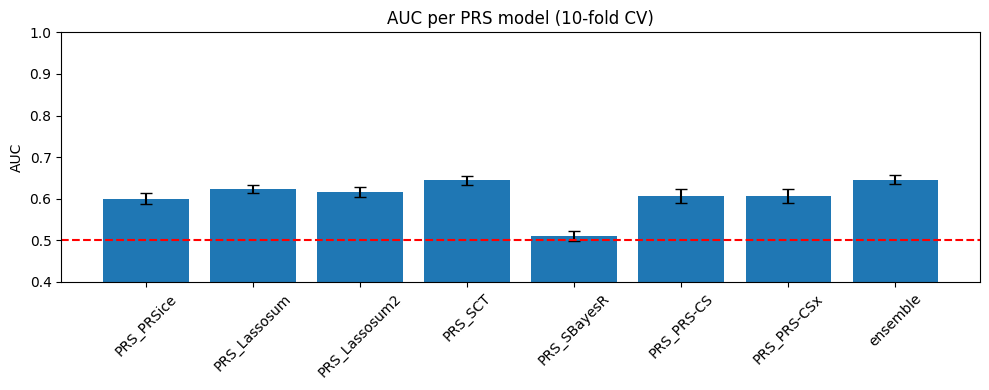

In [191]:
# --- Optional: visualise ---
import matplotlib.pyplot as plt

means = summary.loc['Mean']
stds  = summary.loc['Std']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means.index, means.values, yerr=stds.values, capsize=4)
ax.axhline(0.5, color='red', linestyle='--', label='Random')
ax.set_ylabel('AUC')
ax.set_title('AUC per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_auc_{DATA}_updated.png', dpi=150)
plt.show()

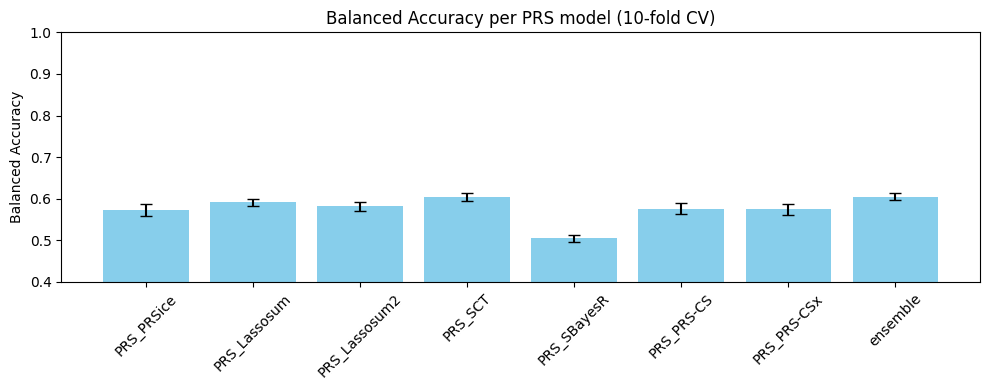

In [192]:
means_accuracy = summary_accuracy.loc['Mean']
stds_accuracy  = summary_accuracy.loc['Std']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means_accuracy.index, means_accuracy.values, yerr=stds_accuracy.values,
         capsize=4, color='skyblue')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Balanced Accuracy per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_balanced_accuracy_{DATA}_updated.png', dpi=150)
plt.show()

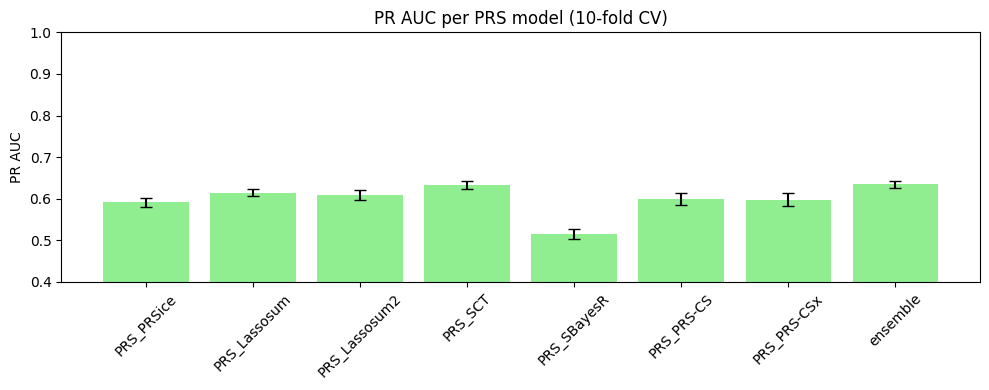

In [193]:
means_pr_auc = summary_pr_auc.loc['Mean']
stds_pr_auc  = summary_pr_auc.loc['Std']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means_pr_auc.index, means_pr_auc.values, yerr=stds_pr_auc.values, capsize=4, color='lightgreen')
ax.set_ylabel('PR AUC')
ax.set_title('PR AUC per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_pr_auc_{DATA}_updated.png', dpi=150)
plt.show()

In [194]:
# calculate mean and std of AUCs across folds for each model, and print in a nice format
for model in summary.columns:
    mean_auc = summary.loc['Mean', model]
    std_auc = summary.loc['Std', model]
    print(f"{model}: AUC = {mean_auc:.4f} ± {std_auc:.4f}")

PRS_PRSice: AUC = 0.6004 ± 0.0140
PRS_Lassosum: AUC = 0.6234 ± 0.0106
PRS_Lassosum2: AUC = 0.6163 ± 0.0115
PRS_SCT: AUC = 0.6439 ± 0.0099
PRS_SBayesR: AUC = 0.5098 ± 0.0116
PRS_PRS-CS: AUC = 0.6071 ± 0.0164
PRS_PRS-CSx: AUC = 0.6066 ± 0.0160
ensemble: AUC = 0.6460 ± 0.0101
